<a href="https://colab.research.google.com/github/aryank2074-ai/rfm-customer-segmentation/blob/main/RFM_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
retail_df=pd.read_excel("Online Retail.xlsx")

In [ ]:
retail_df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [ ]:
retail_df.shape

(541909, 8)

In [ ]:
# Convert the date in YYYY-mm-dd HH:MM format and store that date in "Date" Column
retail_df["Date"]=pd.to_datetime(retail_df["InvoiceDate"],format="%Y-%m-%d %H:%M:%S")

# Count the unique no of attributes in Retail data
def unique_counts(retail_df):
    for i in retail_df.columns:
        count=retail_df[i].nunique()
        print(i,": ",count)
unique_counts(retail_df)

InvoiceNo :  25900
StockCode :  4070
Description :  4223
Quantity :  722
InvoiceDate :  23260
UnitPrice :  1630
CustomerID :  4372
Country :  38
Date :  23260


# Calculate total price by multiplying units and quantity and store that value in separate column total_price

In [ ]:
retail_df["Total_Price"]=retail_df["Quantity"]*retail_df["UnitPrice"]
retail_df.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Date,Total_Price
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,2010-12-01 08:26:00,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010-12-01 08:26:00,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,2010-12-01 08:26:00,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010-12-01 08:26:00,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010-12-01 08:26:00,20.34
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom,2010-12-01 08:26:00,15.30
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.0,United Kingdom,2010-12-01 08:26:00,25.50
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom,2010-12-01 08:28:00,11.10
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom,2010-12-01 08:28:00,11.10
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.0,United Kingdom,2010-12-01 08:34:00,54.08


# Only consider rows without NaN values and store the data in dataset Online_retail_df

In [ ]:
Online_retail_df=retail_df[np.isfinite(retail_df["CustomerID"])]

In [ ]:
unique_counts(Online_retail_df)

InvoiceNo :  22190
StockCode :  3684
Description :  3896
Quantity :  436
InvoiceDate :  20460
UnitPrice :  620
CustomerID :  4372
Country :  37
Date :  20460
Total_Price :  4041


In [ ]:
# For the sake of calculating recency and frequency, drop the rows with negative values of Quantity and store the data in final_retail
final_retail = Online_retail_df[Online_retail_df["Quantity"]>0]
final_retail.shape

(397924, 10)

In [ ]:
unique_counts(final_retail)

InvoiceNo :  18536
StockCode :  3665
Description :  3877
Quantity :  302
InvoiceDate :  17286
UnitPrice :  441
CustomerID :  4339
Country :  37
Date :  17286
Total_Price :  2940


In [ ]:
final_retail["Date"].max()

Timestamp('2011-12-09 12:50:00')

In [ ]:
final_retail["Date"].min()

Timestamp('2010-12-01 08:26:00')

# Q.Calculate RFM value of each customer
### Assumption: In this final dataset, I have removed all the transaction with negative quantity value

In [ ]:
# Calculate recency and frequency
import datetime as dt
NOW=dt.datetime(2011,12,10)

#### Recency(R):Time since last purchase
#### Frequency(F):Total number of purchases
#### Monetory Value(M):Total monetory value

In [ ]:
rfmTable=final_retail.groupby("CustomerID").agg({"Date":lambda x: (NOW - x.max()).days,
                                                "InvoiceNo":lambda x: len(x),
                                                "Total_Price":lambda x: x.sum()})
rfmTable["Date"] = rfmTable["Date"].astype(int)
rfmTable.rename(columns={"Date":"recency",
                        "InvoiceNo":"frequency",
                        "Total_Price":"monetary_value"}, inplace=True)

In [ ]:
rfmTable.shape

(4339, 3)

In [ ]:
rfmTable.head(10)

,recency,frequency,monetary_value
CustomerID,,,
12346.0,325,1,77183.60
12347.0,2,182,4310.00
12348.0,75,31,1797.24
12349.0,18,73,1757.55
12350.0,310,17,334.40
12352.0,36,85,2506.04
12353.0,204,4,89.00
12354.0,232,58,1079.40
12355.0,214,13,459.40


# Q.Find top 10 customers based on frequency and monetary values
### Sorting first on frequency and then on monetary value

In [ ]:
rfmTable.sort_values(["frequency","monetary_value"],ascending=[False,False],inplace=True)

#### Below are top 10 customers after sorting

In [ ]:
rfmTable.head(10)

,recency,frequency,monetary_value
CustomerID,,,
17841.0,1,7847,40991.57
14911.0,1,5677,143825.06
14096.0,4,5111,65164.79
12748.0,0,4596,33719.73
14606.0,1,2700,12156.65
15311.0,0,2379,60767.90
14646.0,1,2080,280206.02
13089.0,2,1818,58825.83
13263.0,1,1677,7454.07


# Q.Find optimal number of segments using dendograms and elbow methods
### seggregate the brands into 3 segments

# Normalising the features

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X_sc=sc.fit_transform(rfmTable)

In [ ]:
clusters=KMeans(3) # 3 clusters
clusters.fit(X_sc)

KMeans(n_clusters=3)

In [ ]:
rfmTable["cluster_new"]=clusters.labels_

In [ ]:
rfmTable.groupby("cluster_new").mean()

,recency,frequency,monetary_value
cluster_new,,,
0,246.813889,27.750926,636.501112
1,40.898644,103.079174,2028.480799
2,4.000000,2566.000000,126118.310000


In [ ]:
rfmTable.drop("cluster_new",axis=1,inplace=True)

In [ ]:
import random
random.seed(9008)
X_sample=np.array(random.sample(X_sc.tolist(),20))

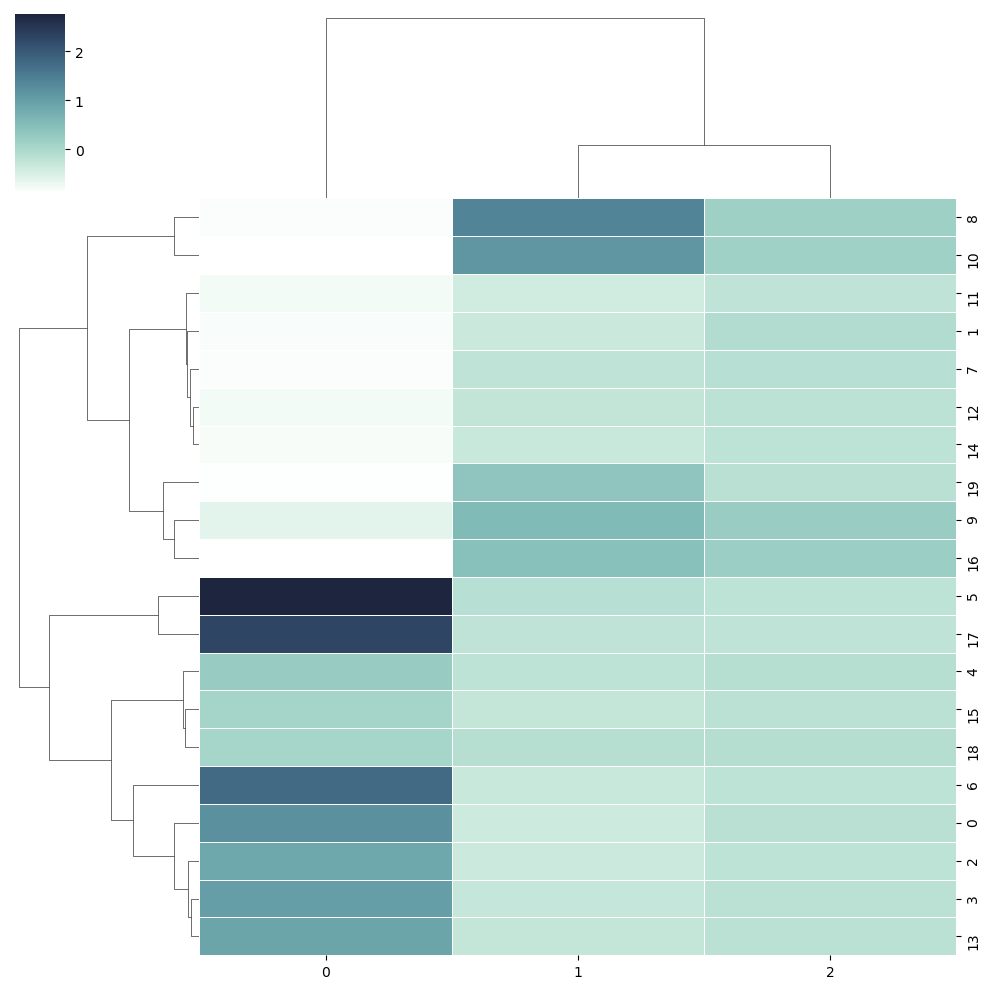

In [ ]:
cmap=sns.cubehelix_palette(as_cmap=True,rot=-.3,light=1)
g=sns.clustermap(X_sample,cmap=cmap,linewidth=.5)

# Consider Elbow method to verify the cluster segmentation

In [ ]:
cluster_range=range(1,10)
cluster_errors=[]

for num_clusters in cluster_range:
    clusters=KMeans(num_clusters)
    clusters.fit(X_sc)
    cluster_errors.append(clusters.inertia_)

In [ ]:
clusters_df = pd.DataFrame( { "num_clusters":cluster_range, "cluster_errors": cluster_errors } )

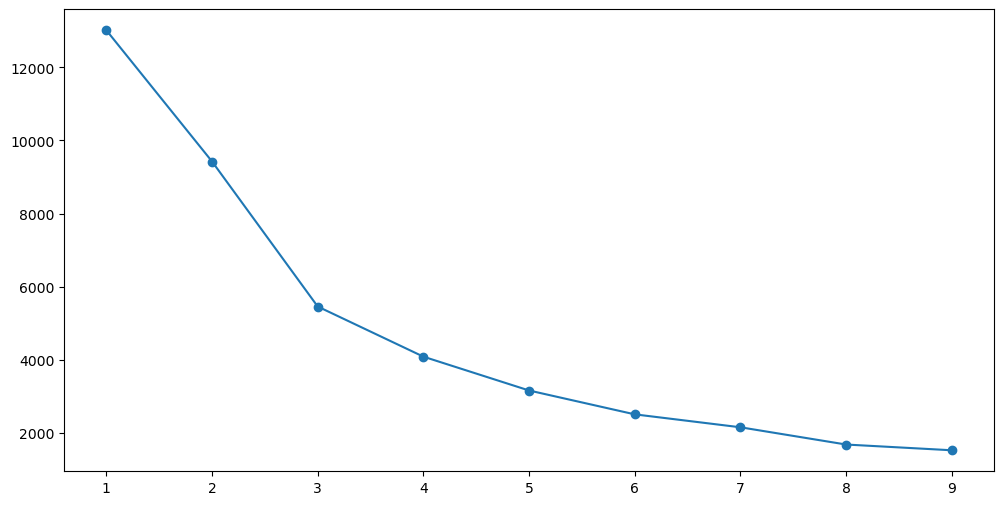

In [ ]:
plt.figure(figsize=(12,6))
plt.plot( clusters_df.num_clusters, clusters_df.cluster_errors, marker = "o" )

In [ ]:
clusters = KMeans(3)  # 3 clusters
clusters.fit( X_sc )
rfmTable["cluster_label"] = clusters.labels_

In [ ]:
rfmTable.groupby('cluster_label').mean()

,recency,frequency,monetary_value
cluster_label,,,
0,40.898644,103.079174,2028.480799
1,246.813889,27.750926,636.501112
2,4.000000,2566.000000,126118.310000


In [ ]:
rfmTable_0 = rfmTable[rfmTable.cluster_label == 0]

# All the customers with high recency and low frequency and low monetory value are segmented in this cluster are the least profitable customers for the company.

In [ ]:
rfmTable_1 = rfmTable[rfmTable.cluster_label == 1]
rfmTable_1.head(10)

,recency,frequency,monetary_value,cluster_label
CustomerID,,,,
17850.0,372,297,5391.21,1
15644.0,166,238,813.00,1
14573.0,179,235,1653.42,1
15808.0,306,208,3734.97,1
15379.0,169,194,3703.29,1
17341.0,156,183,781.36,1
17472.0,191,181,710.29,1
14669.0,241,170,1269.99,1
15574.0,177,168,702.25,1


### Each customer is assigned with the cluster label.

### This cluster has cutomers that are potential customers with decent frequency and monetary value.Company should work towards them to convert them to most profitable customers.


In [ ]:
rfmTable_2 = rfmTable[rfmTable.cluster_label == 2]
rfmTable_2.head(10)

,recency,frequency,monetary_value,cluster_label
CustomerID,,,,
17841.0,1,7847,40991.57,2
14911.0,1,5677,143825.06,2
14096.0,4,5111,65164.79,2
12748.0,0,4596,33719.73,2
15311.0,0,2379,60767.90,2
14646.0,1,2080,280206.02,2
13089.0,2,1818,58825.83,2
14156.0,9,1400,117379.63,2
17511.0,2,963,91062.38,2


### Each customer is assigned with the cluster label.

### All the customers with low recency and high frequency and the monetary value are segmented in this Cluster.

In [ ]:
rfmTable_0.mean()

recency             40.898644
frequency          103.079174
monetary_value    2028.480799
cluster_label        0.000000
dtype: float64

In [ ]:
rfmTable_1.mean()

recency           246.813889
frequency          27.750926
monetary_value    636.501112
cluster_label       1.000000
dtype: float64

In [ ]:
rfmTable_2.mean()

recency                4.00
frequency           2566.00
monetary_value    126118.31
cluster_label          2.00
dtype: float64